# Исследование рынка общественного питания
## Цель и задачи
**Цель:** провести исследовательский анализ рынка общественного питания Москвы, чтобы помочь выбрать подходящее место для нового заведения. 

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных .
4. Сформулировать выводы по проведённому анализу.

## Данные
Для анализа поступили данные о заведениях общественного питания. Данные состоят из двух датасетов:
- `rest_info.csv` - информация о заведениях общественного питания;
- `rest_price.csv` - информация о среднем чеке в заведениях общественного питания

### Данные датасета `rest_info.csv`:
- `id` - id заведения;
- `name` - название заведения;
- `address` -  адрес заведения;
- `district` - административный район, в котором находится заведение, например Центральный административный округ;
- `category` - категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` - информация о днях и часах работы;
- `rating` - рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` - число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки): 0 — заведение не является сетевым; 1 — заведение является сетевым;
- `seats` - количество посадочных мест.

### Данные датасета `rest_price.csv`:
- `id` - id заведения;
- `price` - категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` -  хранит среднюю стоимость заказа в виде диапазона, например:
«Средний счёт: 1000–1500 ₽»;
«Цена чашки капучино: 130–220 ₽»;
«Цена бокала пива: 400–600 ₽»
и так далее;
- `middle_avg_bill` - число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` - число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Структура проекта
1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации

## 1. Загрузка данных и знакомство с ними

Загрузим необходимые библиотеки и данные из датасетов `rest_info.csv` и `rest_price.csv` в переменные `df_1` и `df_2`.

In [1]:
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd

#Импортируем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

#Импортируем библиотеку для расчета коэффициента корреляции phik
from phik import phik_matrix

In [3]:
#Загружаем данные из датасетов в переменные df_1 и df_2
df_1 = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
df_2 = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Сначала познакомимся с данными датасета `rest_info.csv`. Выведем первые 5 строк датасета и общую информацию о нем:

In [4]:
#выведем первые 5 строк датасета
df_1.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
#выведем основную информацию о датасете 
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит `8406` строк и `9` столбцов, в которых хранится информация о заведениях общественного питания. После первичного анализа можно сделать следующие выводы:
- Названия столбцов записаны в удобном формате.
- Данные соответствуют описанию.
- Во всех столбцах подходящие типы данных, но в столбцах `rating`, `chain` и `seats` можно оптимизировать и подобрать тип с меньшей разрядностью.
- В столбцах `hours` и `seats` содержатся пропуски. Это может быть связано с технической ошибкой при сборе данных или с отсутствием этой информации.

Далее так же познакомимся с датасетом `rest_price.csv`:

In [6]:
#выведем первые 5 строк датасета
df_2.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
#выведем основную информацию о датасете 
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит `4058` строк и `5` столбцов, в которых хранится информация о среднем чеке в заведениях общественного питания. После первичного анализа можно сделать следующие выводы:
- Названия столбцов записаны в удобном формате.
- Данные соответствуют описанию.
- Во всех столбцах подходящие типы данных, однако в столбцах `middle_avg_bill` и `middle_coffee_cup` стоит попробовать изменить разрядность на более оптимальную.
- В столбцах `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` содержатся пропуски. В столбцах `price` и `avg_bill` пропуски могли возникнуть из-за технической ошибки, однако стоит изучить, случайны ли они или с чем-то связаны. Столбцы `middle_avg_bill`, `middle_coffee_cup` зависят от столбца `avg_bill`, поэтому пропуски в них появляются, если в `avg_bill` пропуск или если в `avg_bill` содержится информация не о среднем счете и не о кофе, а например о цене бокала пива.

Объединим данные датасетов `rest_info.csv` и `rest_price.csv` в один для дальнейшего анализа. 

In [8]:
#используем соединение left, чтобы не потерять данные о заведениях, у которых нет информации о средних ценах 
df = df_1.merge(df_2, on = 'id', how = 'left')
#выведем информацию о получившемся датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Мы получили датасет со всеми необходимыми данными. Далее сделаем предобработку данных.

## 2. Предобработка данных
### 2.1 Преобразование типов данных
Преобразуем тип данных в столбцах `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` с `float64` на более оптимальный, и в `seats` с `int64` на более оптимальный.

Сохраним в переменную кол-во строк в датафрейме до предобработки:

In [9]:
df_len = df.shape[0]
df_len

8406

Преобразуем тип данных в столбцах `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` с `float64` на более оптимальный, и в `seats` с `int64` на более оптимальный.

In [10]:
# используем параметр downcast, чтобы подобрать оптимальную разрядность
# преобразуем тип данных в chain
df['chain'] = pd.to_numeric(df['chain'], downcast = 'integer')

# преобразуем тип данных в остальных столбцах
for i in ['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']:
    df[i] = pd.to_numeric(df[i], downcast = 'float')

# проверяем, что получилось
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

Типы данных были успешно оптимизированы с понижением размерности:
- в `chain` с int64 на int8
- в `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` с float64 на float32
### 2.2 Проверка пропусков
Посмотрим, сколько пропусков в каждом столбце датафрейма:

In [11]:
# считаем кол-во пропусков в каждом столбце
df.isna().sum() 

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Найдем относительное количество пропусков:

In [12]:
(df.isna().sum() / df.shape[0]) * 100

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

Пропуски в `hours` и `seats` могли появиться из-за ошибки при сборе данных или из-за отсутствия этой информации. Удалять эти пропуски мы не будем, так как можем потерять большую часть данных. В поле `hours` мы заменим пропуски на "Нет информации", а в `seats` мы оставим всё как есть, так как при дальнейшем анализе значения-индикаторы могут помешать.

In [13]:
# заменим пропуски в hours на "Нет информации"
df['hours'] = df['hours'].fillna('Нет информации')
# проверим результат
df['hours'].isna().sum()

0

В полях `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` содержится много пропусков (больше 40% везде), так как мы объединили два датасета, и во втором датасете была информация не про все заведения, которые есть в первом. Также там изначально было немало пропусков. В поле `price` и `avg_bill`, предположительно, из-за технической ошибки при сборе данных. В полях `middle_avg_bill` и `middle_coffee_cup` пропуски скорее всего зависят от столбца `avg_bill`. Изучим строки, где содержится пропуск в `middle_avg_bill`:

In [14]:
# выведем первые 5 строк, где пропущенно значение middle_avg_bill
df[df['middle_avg_bill'].isna()].head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN
10,ac32978af97641bfacf996e7f5a50ee5,Great Room Bar,"бар,паб","Москва, Левобережная улица, 12",Северный административный округ,"ежедневно, круглосуточно",4.5,0,102.0,средние,Цена бокала пива:250–350 ₽,NaN,NaN
11,53ac103717c142f29907080db1f0ce58,Шашлык Шефф,кафе,"Москва, улица Маршала Федоренко, 10с1",Северный административный округ,"ежедневно, 10:00–21:00",4.9,0,NaN,NaN,NaN,NaN,NaN


Как мы видим, пропуск в `middle_avg_bill` возникает, если в поле `avg_bill` содержится пропуск или содержится другая информация, не связанная со счётом (например, про цену чашки кофе или бокала пива). Не будем заменять пропуски на индикаторы, оставим строки в таком виде, так как это удобнее для дальнейшей группировки и анализа.
Также посмотрим на строки, где содержится пропуск в `middle_coffee_cup`:

In [15]:
# выведем первые 5 строк, где пропущенно значение middle_coffee_cup
df[df['middle_coffee_cup'].isna()].head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN


Пропуск в `middle_coffee_cup` возникает, если в поле `avg_bill` содержится пропуск или содержится другая информация, не связанная с ценой чашки кофе. Здесь мы также не будем заменять пропуски на индикаторы.
### 2.3 Явные и неявные дубликаты в данных
Проверим данные на наличие явных и неявных дубликатов. Начнём с явных:

In [16]:
# выводим количество явных дубликатов в df
df.duplicated().sum()

0

Далее проверим дубликаты в поле `id`, все значения в этом поле должны быть уникальными.

In [17]:
# выводим количество дубликатов в поле id
df.duplicated(subset = 'id').sum()

0

Дубликатов в поле `id` нет, все значения уникальные. Проверим уникальные значения в категориальных столбцах:

In [18]:
# выведем уникальные значения категориальных столбцов
for i in ['category', 'district', 'chain', 'price']:
    print(f'Уникальные значения {i}: {df[i].unique()}')

Уникальные значения category: ['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']
Уникальные значения district: ['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']
Уникальные значения chain: [0 1]
Уникальные значения price: [nan 'выше среднего' 'средние' 'высокие' 'низкие']


В категориальных столбцах нет ошибок.

Приведем все адреса и названия к нижнему регистру и проверим дубликаты.


In [19]:
# приводим названия и адреса к нижнему регистру
df['address'] = df['address'].str.lower()
df['name'] = df['name'].str.lower()

# проверяем дубликаты
df.duplicated(subset = ['name', 'address']).sum()

4

Есть 4 дубликата, удалим их:

In [20]:
# удаляем дубликаты
df = df.drop_duplicates(subset = ['name', 'address'])


### 2.4 Создание новых столбцов
Для дальнейшей работы выделим новый столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
- логическое значение `True` — если заведение работает ежедневно и круглосуточно;
- логическое значение `False` — в противоположном случае.


In [21]:
# создаем функцию для категоризации
def categorize(row):
    if 'ежедневно, круглосуточно' in row:
        return True
    else:
        return False
# применяем функцию ко всем строкам столбца hours
is_24_7 = df['hours'].apply(categorize)
# создаем новый столбец
df['is_24_7'] = is_24_7
# проверим, правильно ли создался столбец
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


Сохраним в переменную кол-во строк в датафрейме после предобработки и посчитаем какую долю строк мы удалили.

In [22]:
df_new_len = df.shape[0]
print(f'Было удалено {round((df_len-df_new_len)/df_len*100, 2)} % строк')

Было удалено 0.05 % строк


---
#### В ходе предобработки данных мы сделали следующее:
- Оптимизировали типы данных с понижением размерности в столбцах `chain`, `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup`.
- Посчитали количество пропусков. В поле `hours` заменили пропуски на "Нет информации", в столбцах  `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` оставили пропуски, так как это удобнее для дальнейшего анализа.
- Проверили данные на наличие явных и неявных дубликатов. Удалили 4 строки, где дублировалось название заведения и адрес.
- Создали новый столбец `is_24_7`, показывающий, работает ли заведение ежедневно и круглосуточно или нет.

Итого было удалено 0,05% строк.

---

## 3. Исследовательсикй анализ данных

### 3.1. Исследуем количество объектов общественного питания по каждой категории. 

Посчитаем, сколько заведений относятся к каждой категории:

In [23]:
# посчитаем, сколько заведений в каждой категории
df['category'].value_counts()

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

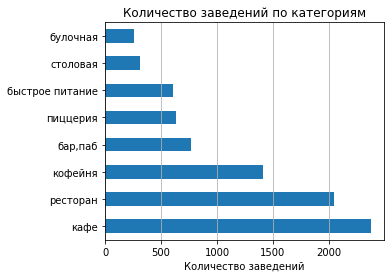

In [24]:
# создаем линейчатую диаграмму с количеством заведений по категориям
df['category'].value_counts().plot(kind = 'barh', figsize = (5, 4))

# настраиваем оформление графика
plt.grid(axis = 'x')
plt.title('Количество заведений по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('')

# выводим график
plt.show()

Видно, что больше всего в Москве кафе(2378) и ресторанов(2043), а меньше всего булочных(256) и столовых(315). 

### 3.2 Исследуем распределение количества заведений по административным районам Москвы.

Посчитаем, сколько заведений открыто в каждом районе Москвы:

In [25]:
# Посчитаем количество заведений в каждом районе Москвы
df['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

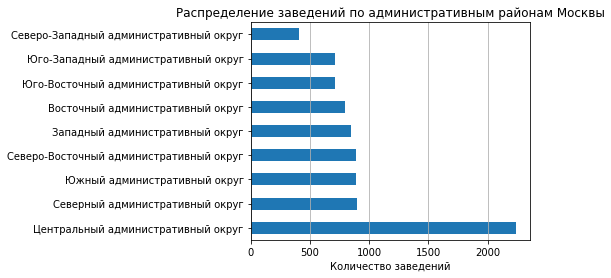

In [26]:
# создаем линейчатую диаграмму с количеством заведений по районам
df['district'].value_counts().plot(kind = 'barh', figsize = (5, 4))

# настраиваем оформление графика
plt.grid(axis = 'x')
plt.xlabel('Количество заведений')
plt.ylabel('')
plt.title('Распределение заведений по административным районам Москвы')

# выводим график
plt.show()

Видно, что наибольшее количество заведений находится в Центральном административном округе (2242), а наименьшее количество в Северно-Западном(409). В остальных районах заведений примерно одинаково. Изучим отдельно распределение заведений каждой категории в Центральном административном округе Москвы: 

In [27]:
# создаем датафрейм с данными Центрального округа
filtered = df[df['district'] == 'Центральный административный округ']

# считаем количество заведений каждой категории
filtered['category'].value_counts()

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

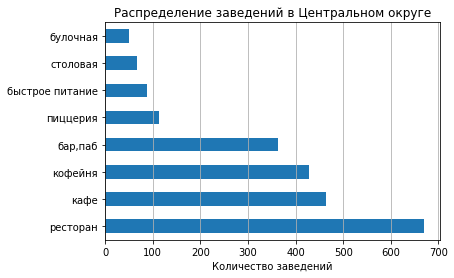

In [28]:
# создаем линейчатую диаграмму с количеством заведений в Центральном районе
filtered['category'].value_counts().plot(kind = 'barh')

# настраиваем оформление графика
plt.grid(axis = 'x')
plt.title('Распределение заведений в Центральном округе')
plt.xlabel('Количество заведений')
plt.ylabel('')

# выводим график
plt.show()

Распределение количества заведений по категориям в Центральном округе такое же, как и в целом по Москве. Самые частые заведения - рестораны и кафе, самые редкие - булочные и столовые.

### 3.3 Изучим соотношение сетевых и несетевых заведений. 
Сначала изучим соотношение в целом по всем данным: 

In [29]:
# посчитаем количество сетевых и несетевых заведений
df['chain'].value_counts()

0    5199
1    3203
Name: chain, dtype: int64

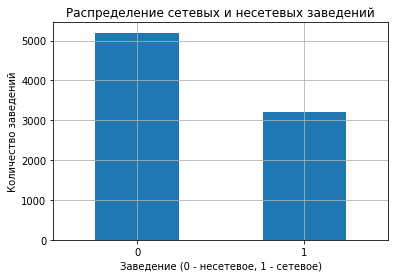

In [30]:
# построим столбчатую диаграмму с количеством сетевых и несетевых заведений
df['chain'].value_counts().plot(kind = 'bar', rot = 0)

# настраиваем оформление графика
plt.grid()
plt.title('Распределение сетевых и несетевых заведений')
plt.xlabel('Заведение (0 - несетевое, 1 - сетевое)')
plt.ylabel('Количество заведений')

# выводим график
plt.show()

Несетевых заведений значительно больше (5201), чем сетевых (3205). Это может быть связано с тем, что открыть несколько сетевых заведений значительно сложнее, чем одно.

Теперь посмотрим на соотношение сетевых и несетевых заведений в разрезе категорий заведения. 

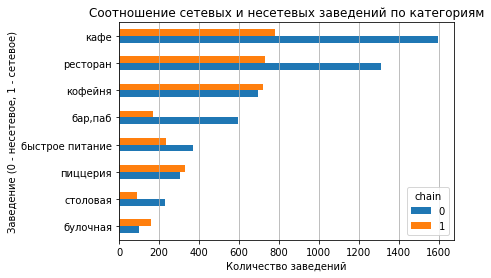

In [31]:
# сгруппируем заведения по категориям и по сетевым/несетевым
grouped = df.groupby(['category', 'chain'])['id'].count().unstack()

# сортируем по количеству несетевых заведений
grouped = grouped.sort_values(by = 0)

# построим линейчатую диаграмму с соотношением сетевых и несетевых заведений в разрезе категорий
grouped.plot(kind = 'barh')

# настраиваем оформление графика
plt.grid(axis = 'x')
plt.title('Соотношение сетевых и несетевых заведений по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Заведение (0 - несетевое, 1 - сетевое)')

# выводим график
plt.show()

На графике видно, что сетевыми чаще являются `кофейня`, `пиццерия` и `булочная`.

### 3.4. Исследуем количество посадочных мест в заведениях.

Сначала посмотрим на основные статистические показатели по посадочным местам:

In [32]:
# выведем основные статистические показатели 
df['seats'].describe()

count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Среднее значение (108) отличается от медианы (75), и стандартное отклонение достаточно большое (122), что свидетельствует о наличии выбросов в данных. Минимальное значение посадочных мест равно 0. Возможно это либо является ошибкой в данных, либо в этом заведении еда только на вынос и внутри нельзя сидеть. Стоит проверить, в каких заведениях 0 мест:

In [33]:
# создаем датафрейм, в котором данные о заведениях с 0 местами
new_df = df[df['seats'] == 0]

# выводим количество заведений, в которых 0 мест
print(f'В {new_df.shape[0]} заведениях 0 мест:')

# выводим такие заведения
new_df['category'].unique()

В 136 заведениях 0 мест:


array(['булочная', 'ресторан', 'кафе', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'столовая'], dtype=object)

Всего в датасете 136 заведений, в которых 0 посадочных мест. Маловероятно, что, например, в ресторане или баре не будет ни одного посадочного места. Это больше похоже на ошибку в данных, либо заведение оформляет онлайн заказы и поэтому в базе данных хранится такая информация. 

Изучим выбросы в данных с помощью диаграммы размаха:

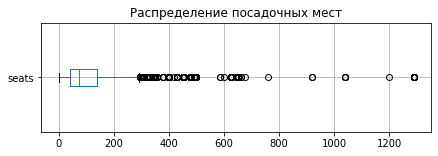

In [34]:
# создаем диаграмму размаха по столбцу seats
df['seats'].plot(kind = 'box', vert = False, figsize = (7, 2))

# настраиваем оформление графика
plt.title('Распределение посадочных мест')
plt.grid()

# выводим график
plt.show()

В основном количество посадочных мест находится в диапозоне от 0 до 300. Также есть выбросы в данных - заведения, где больше 300 мест. Исследуем среднее количество посадочных мест по категориям заведений:

In [35]:
# считаем среднее количество мест по категориям
grouped = df.groupby('category')['seats'].mean().sort_values()
grouped

category
булочная            89.385132
пиццерия            94.496490
кафе                97.365654
быстрое питание     98.891121
столовая            99.750000
кофейня            111.199730
ресторан           121.892044
бар,паб            124.477516
Name: seats, dtype: float32

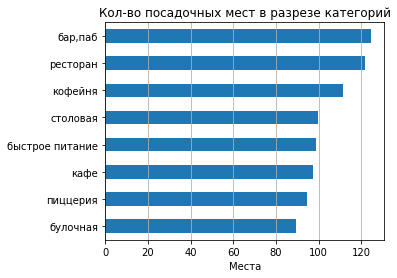

In [36]:
# создадим линейчатую диаграмму с кол-вом посадочных мест в разрезе категорий
grouped.plot(kind = 'barh', figsize = (5, 4))

# настраиваем оформление графика
plt.title('Кол-во посадочных мест в разрезе категорий')
plt.xlabel('Места')
plt.ylabel('')
plt.grid(axis = 'x')

# выводим график
plt.show()

По этому графику можно сказать, что больше всего посадочных мест в категориях `бар, паб` и `ресторан`, а меньше всего в `булочная` и `пиццерия`. Попробуем посмотреть на среднее количество посадочных мест в разрезе категорий без выбросов в данных:

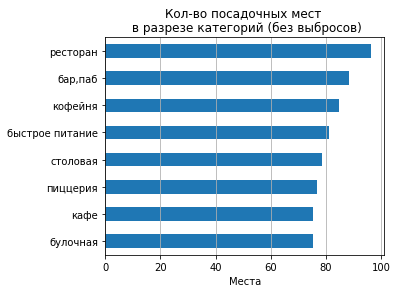

In [37]:
# найдем межквартильный размах
iqr = df['seats'].quantile(0.75) - df['seats'].quantile(0.25)

# оставим данные о посадочных местах без выбросов
filt = df[(df['seats'] > df['seats'].quantile(0.25) - 1.5*iqr) & (df['seats'] < df['seats'].quantile(0.75) + 1.5*iqr)]

# найдем среднее кол-во мест по категориям
grouped = filt.groupby('category')['seats'].mean().sort_values()

# создадим линейчатую диаграмму с кол-вом посадочных мест в разрезе категорий
grouped.plot(kind = 'barh', figsize = (5, 4))

# настраиваем оформление графика
plt.title('Кол-во посадочных мест \n в разрезе категорий (без выбросов)')
plt.xlabel('Места')
plt.ylabel('')
plt.grid(axis = 'x')

# выводим график
plt.show()

По этому графику можно сказать, что больше всего посадочных мест так же в категориях `ресторан` и `бар, паб`, а меньше всего в `булочная` и `кафе`. 

### 3.5. Исследуем рейтинг заведений. 
Посчитаем средний рейтинг в разрезе категорий заведений: 

In [38]:
rating = df.groupby('category')['rating'].mean().sort_values()
rating

category
быстрое питание    4.050249
кафе               4.124285
столовая           4.211429
булочная           4.268359
кофейня            4.277282
ресторан           4.290401
пиццерия           4.301264
бар,паб            4.387696
Name: rating, dtype: float32

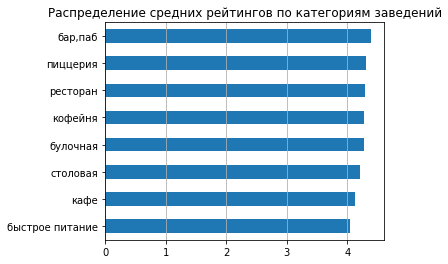

In [39]:
# построим линейчатую диаграмму распределения рейтингов по категориям заведений
rating.plot(kind = 'barh', figsize = (5, 4))

#настраиваем оформление графика
plt.title('Распределение средних рейтингов по категориям заведений')
plt.ylabel('')
plt.grid(axis = 'x')

# выводим график
plt.show()

Самым высоким рейтингом обладает `бар, паб` (4,39), а самым низким - `быстрое питание` (4,05). Кажется, что средние рейтинги заведений не особо отличаются друг от друга. Посчитаем стандартное отклонение.

In [40]:
# считаем стандратное отклонение
rating.std()

0.107240506

Стандартное отклонение небольшое, средние рейтинги распределены практически равномерно.

### 3.6. Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. 
Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным:

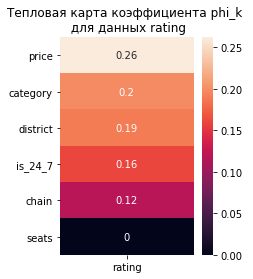

In [41]:
# создаем матрицу корреляций rating с другими признаками
corr_columns = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
interval = ['rating', 'seats']
corr_matrix = df[corr_columns].phik_matrix(interval_cols = interval)

# создаем тепловую карту корреляций rating с другими признаками
plt.figure(figsize = (3, 4))
data_heatmap = corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data = data_heatmap, annot = True)
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')

# выводим график
plt.show()

По графику видно, что самая сильная связь у `price` с `rating` (0,26). Проверим эту связь, найдем средний рейтинг для каждой категории цен.

In [42]:
# найдем средний рейтинг для каждой категории цен
grouped= df.groupby('price')['rating'].mean().sort_values()
grouped

price
низкие           4.173077
средние          4.297874
выше среднего    4.386348
высокие          4.436611
Name: rating, dtype: float32

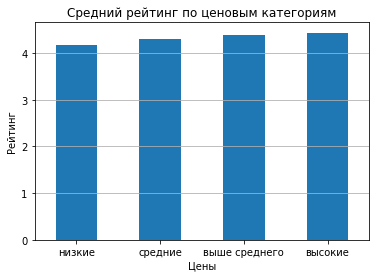

In [43]:
# построим столбчатую диаграмму с рейтингом по ценовым категориям
grouped.plot(kind = 'bar', rot = 0)

# настраиваем оформление графика
plt.grid(axis = 'y')
plt.xlabel('Цены')
plt.ylabel('Рейтинг')
plt.title('Средний рейтинг по ценовым категориям')

# выводим график
plt.show()

Видно, что между категорией цен и рейтингом есть положительная связь: чем выше цены в заведении, тем выше у него рейтинг. Это может быть связано с тем, что:
- Чем выше цены, тем качественне могут использоваться продукты, соответственно вкуснее блюда и выше рейтинг.
- Чем выше цены, тем лучше интерьер, обстановка, соответственно выше рейтинг.

### 3.7. Найдем топ-15 популярных сетей в Москве 
Посчитаем, каких сетевых заведений открыто больше всего в регионе. 

In [44]:
# оставим только сетевые заведения, сгруппируем по названию, категории и подсчитаем их количество
popular = df[df['chain'] == 1].groupby(['name', 'category']).agg({'name' : 'count', 'rating' : 'mean'})
popular.columns = ['count', 'rating']

# отсортируем в порядке убывания и выведем топ-15
popular = popular.sort_values(by = 'count', ascending = False).head(15)
popular

,,count,rating
name,category,,
шоколадница,кофейня,119,4.178151
домино'с пицца,пиццерия,76,4.169737
додо пицца,пиццерия,74,4.286487
one price coffee,кофейня,71,4.064789
яндекс лавка,ресторан,69,3.872464
cofix,кофейня,65,4.075385
prime,ресторан,49,4.114285
кофепорт,кофейня,42,4.147619
кулинарная лавка братьев караваевых,кафе,39,4.394872


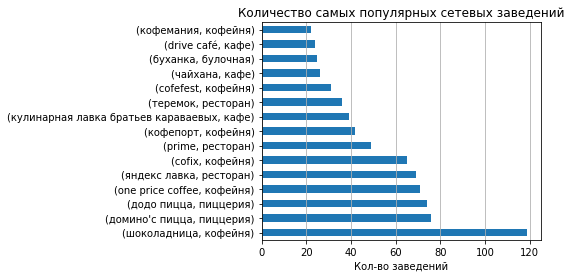

In [45]:
# постром линейчатую диаграмму с количеством самых популярных заведений
count_popular = popular.sort_values(by = 'count', ascending = False).head(15)
count_popular['count'].plot(kind = 'barh', figsize = (5, 4))

# настраиваем оформление графика
plt.title("Количество самых популярных сетевых заведений")
plt.grid(axis = 'x')
plt.ylabel('')
plt.xlabel('Кол-во заведений')

# выводим график
plt.show()

Посчитаем средний рейтинг для этих заведений:

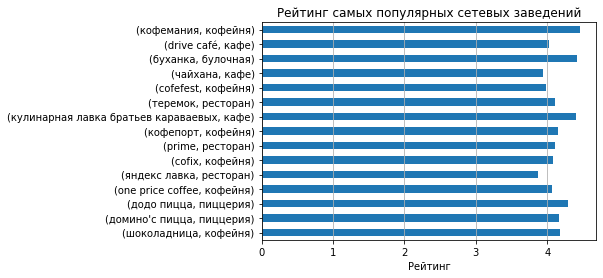

In [46]:
# постром линейчатую диаграмму с рейтингом самых популярных заведений
rating_popular = popular.sort_values(by = 'count', ascending = False).head(15)
rating_popular['rating'].plot(kind = 'barh')

# настраиваем оформление графика
plt.title('Рейтинг самых популярных сетевых заведений')
plt.grid(axis = 'x')
plt.ylabel('')
plt.xlabel('Рейтинг')

# выводим график
plt.show()

Как мы видим, рейтинг распределен хаотично, и не особо связан с количеством заведений.

Посчитаем, сколько популярных заведений в каждой категории:

In [47]:
# группируем по категориям и считаем сколько всего заведений
popular.groupby('category')['count'].sum().sort_values()

category
булочная     25
кафе         89
пиццерия    150
ресторан    154
кофейня     350
Name: count, dtype: int64

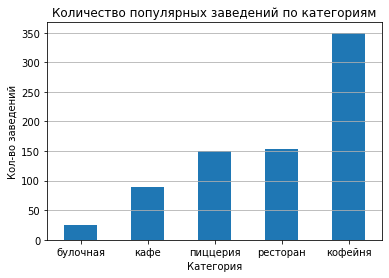

In [48]:
# строим столбчатую диаграмму с количеством заведений в разрезе категорий
data = popular.groupby('category')['count'].sum().sort_values()
data.plot(kind = 'bar', rot = 0)

# настраиваем оформление графика
plt.title('Количество популярных заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Кол-во заведений')
plt.grid(axis = 'y')

# выводим график
plt.show()

Итак, в топ-15 популярных заведений входят заведения из категорий: `булочная, кафе, пиццерия, ресторан, кофейня`. Среди топа-15 больше всего открыто кофеен, а меньше всего - булочных. Это может быть связано с тем, что кофейню может быть открыть гораздо проще, ведь для этого не требуется большая площадь, и можно разместить ее даже в переходе в метро. Кофе люди в Москве, в связи с их ритмом жизни, покупают часто.

### 3.8. Изучим вариацию среднего чека заведения в зависимости от района Москвы. 
Сначала посмотрим на основные статистические показатели по столбцу со средним чеком:

In [49]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Среднее значение(958) отличается от медианы(750), стандартное отклонение довольно большое (1009), что говорит о выбросах в данных. Найдем медиану среднего чека:

In [50]:
grouped = df.groupby('district')['middle_avg_bill'].median().sort_values()
grouped

district
Юго-Восточный административный округ        450.0
Северо-Восточный административный округ     500.0
Южный административный округ                500.0
Восточный административный округ            575.0
Юго-Западный административный округ         600.0
Северный административный округ             650.0
Северо-Западный административный округ      700.0
Западный административный округ            1000.0
Центральный административный округ         1000.0
Name: middle_avg_bill, dtype: float32

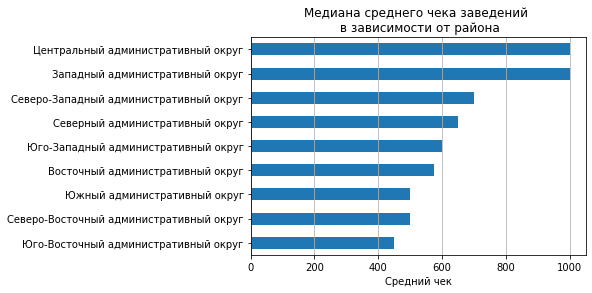

In [51]:
# строим линейчатую диаграмму с медианой среднего чека по районам
grouped.plot(kind = 'barh')

# настраиваем оформление графика
plt.title('Медиана среднего чека заведений \n в зависимости от района')
plt.xlabel('Средний чек')
plt.ylabel('')
plt.grid(axis = 'x')

# выводим график
plt.show()

По графику видно, что самый высокий средний чек в Центральном(1000) и Западном(1000) администритивном округе. Самый низкий средний чек в Юго-Восточном округе.

## 4. Итоговый вывод и рекомендации

### Обзор проделанной работы
В ходе исследования мы изучили данные 8406 заведений общественного питания Москвы. Мы познакомились с данными, провели предобработку, изучили детально данные и проанализировали взаимосвязи между ними. Цель исследования была помочь выбрать подходящий тип заведения и место для его открытия, поэтому мы исследовали расположение, средний чек, рейтинг и другие показатели, которые важны для этого выбора.   

### Главные выводы


- Больше всего в Москве открыто `кафе` и `ресторанов`, меньше всего - `булочных`.
- Больше всего заведений расположено в `Центральном` округе, меньше всего - в `Северо-Западном`. В остальных районах заведений примерно поровну.
- Несетевых заведений значительно больше, чем сетевых. Чаще всего сетевыми являются `кофейни`, `пиццерии` и `булочные`.
- Посадочных мест больше всего в `барах` и `ресторанах`, меньше всего в `булочных`.
- Самый высокий рейтинг у `баров`, самый низкий у  `быстрого питания`.
- Чем выше цены в заведении, тем выше рейтинг.
- Заведений `Шоколадница` (кофейня) открыто больше всего в Москве.
- Самый большой средний чек в заведениях `Центрального` и `Западного` округа, самый низкий - в `Юго-Восточном`.

### Рекоммендации
Выгодно открыть заведение в Центральном округе, так как там самый высокий средний чек (1000). В ходе исследования мы узнали, что чем выше цены, тем выше рейтинг заведения, который будет привлекать больше клиентов. Хорошим вариантом будет открыть бар, паб, так как их в Центральном округе среднее количество - 364 (больше всего отркыто ресторанов - 670, меньше всего булочных - 50).  Среднее количество посадочных мест в барах самое большое среди других категорий заведений (124), следовательно больше людей могут посещать бар и приносить больше денег.